# UDL Representation Learning Assignment — CIFAR-10 & MNIST Dataset

### Group 102

| Member Name | BITS Id |
|----------|----------|
| NEHA NARULA | 2024ad05444 |
| RIYA NARULA | 2024ad05445 |
| RAHUL. | 2024ad05284 |
| THAKUR CHIRAG MUKESH | 2024ad05302 |
| SUMATHI D. | 2024ad05499 |

**Datasets covered:**
- CIFAR-10 (RGB → grayscale, resized to 28×28, intensities [50, 200])
- MNIST handwritten digits (28×28 grayscale, intensities [50, 200])

Both datasets use a stratified **70 % train / 20 % validation / 10 % test** split.

In [ ]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.metrics import roc_curve, auc, accuracy_score
from scipy.optimize import linear_sum_assignment
from scipy.linalg import subspace_angles
import pandas as pd

from IPython.display import display

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Utilities

In [ ]:
def scale_intensity(x):
    x = x.astype(np.float32)
    return 50.0 + (x / 255.0) * 150.0


def snr_db(original, reconstructed, eps=1e-10):
    orig  = original.reshape(len(original), -1)
    recon = reconstructed.reshape(len(reconstructed), -1)
    signal_power = np.sum(orig ** 2, axis=1)
    noise_power  = np.sum((orig - recon) ** 2, axis=1) + eps
    return float(np.mean(10.0 * np.log10(signal_power / noise_power)))


def plot_components(components, title, n_show=30, ncol=6):
    n = min(n_show, len(components))
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 1.5, nrow * 1.5))
    axes = np.atleast_1d(axes).flatten()
    vmin, vmax = components.min(), components.max()
    for i in range(nrow * ncol):
        axes[i].axis('off')
        if i < n:
            axes[i].imshow(components[i].reshape(28, 28), cmap='gray', vmin=vmin, vmax=vmax)
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


def plot_roc_micro(y_true, y_score, label, ax=None):
    classes = np.unique(y_true)
    y_bin = label_binarize(y_true, classes=classes)
    fpr, tpr, _ = roc_curve(y_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    ax.plot(fpr, tpr, label=f'{label} (AUC={roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    return roc_auc


def subspace_metrics(U, V):
    Qu, _ = np.linalg.qr(U)
    Qv, _ = np.linalg.qr(V)
    angles = subspace_angles(Qu, Qv)
    return {
        'mean_angle_deg':  np.degrees(np.mean(angles)),
        'max_angle_deg':   np.degrees(np.max(angles)),
        'proj_frobenius':  np.linalg.norm(Qu @ Qu.T - Qv @ Qv.T, 'fro'),
    }


def greedy_correlation(components_pca, W):
    corrs = np.zeros((30, 30))
    for i in range(30):
        for j in range(30):
            corrs[i, j] = np.abs(np.corrcoef(components_pca[i].flatten(), W[:, j].flatten())[0, 1])
    row_ind, col_ind = linear_sum_assignment(-corrs)
    return float(np.mean(corrs[row_ind, col_ind])), corrs, col_ind


def fit_logistic_classifier(Z_train, y_train, Z_test, max_iter=10000):
    scaler = StandardScaler()
    Z_tr = scaler.fit_transform(Z_train)
    Z_te = scaler.transform(Z_test)
    clf  = LogisticRegression(max_iter=max_iter, solver='lbfgs', random_state=SEED)
    clf.fit(Z_tr, y_train)
    return clf, scaler, clf.predict_proba(Z_te), clf.predict(Z_te)


def stratified_split_70_20_10(X, y, seed=SEED):
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.10, stratify=y, random_state=seed)
    val_ratio = 0.20 / 0.90
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_ratio, stratify=y_temp, random_state=seed)
    return X_train, X_val, X_test, y_train, y_val, y_test

## Dataset 1 — CIFAR-10 (RGB → grayscale, 28×28)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
CIFAR-10: train (42000, 784), val (12000, 784), test (6000, 784)


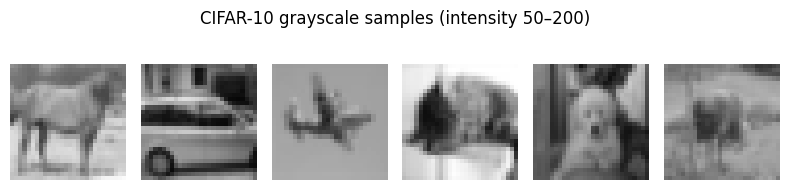

In [ ]:
def rgb_to_gray(images):
    return (0.299 * images[..., 0] +
            0.587 * images[..., 1] +
            0.114 * images[..., 2]).astype(np.float32)


def load_and_preprocess_cifar10_gray():
    (x_tr, y_tr), (x_te, y_te) = keras.datasets.cifar10.load_data()
    x = np.concatenate([x_tr, x_te], axis=0).astype(np.float32)
    y = np.concatenate([y_tr, y_te], axis=0).reshape(-1)
    gray    = rgb_to_gray(x)
    gray_28 = tf.image.resize(gray[..., np.newaxis], (28, 28)).numpy()[..., 0]
    return scale_intensity(gray_28), y


def prepare_cifar10():
    X_img, y = load_and_preprocess_cifar10_gray()
    X_flat   = X_img.reshape(len(X_img), -1)
    X_train, X_val, X_test, y_train, y_val, y_test = stratified_split_70_20_10(X_flat, y)
    to_img   = lambda Xf: Xf.reshape(-1, 28, 28, 1)
    data = {
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
        'X_train_img': to_img(X_train), 'X_val_img': to_img(X_val), 'X_test_img': to_img(X_test),
    }
    print(f"CIFAR-10: train {X_train.shape}, val {X_val.shape}, test {X_test.shape}")
    return data

data_cifar = prepare_cifar10()

fig, ax = plt.subplots(1, 6, figsize=(8, 2))
for i in range(6):
    ax[i].imshow(data_cifar['X_train'][i].reshape(28, 28), cmap='gray', vmin=50, vmax=200)
    ax[i].axis('off')
fig.suptitle('CIFAR-10 grayscale samples (intensity 50–200)')
plt.tight_layout(); plt.show()

## Dataset 2 — MNIST (28×28 grayscale)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MNIST: train (48999, 784), val (14001, 784), test (7000, 784)


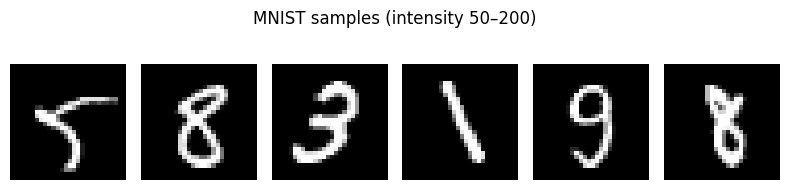

In [ ]:
def load_and_preprocess_mnist():
    (x_tr, y_tr), (x_te, y_te) = keras.datasets.mnist.load_data()
    x = np.concatenate([x_tr, x_te], axis=0).astype(np.float32)
    y = np.concatenate([y_tr, y_te], axis=0)
    return scale_intensity(x), y


def prepare_mnist():
    X_img, y = load_and_preprocess_mnist()
    X_flat   = X_img.reshape(len(X_img), -1)
    X_train, X_val, X_test, y_train, y_val, y_test = stratified_split_70_20_10(X_flat, y)
    to_img   = lambda Xf: Xf.reshape(-1, 28, 28, 1)
    data = {
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
        'X_train_img': to_img(X_train), 'X_val_img': to_img(X_val), 'X_test_img': to_img(X_test),
    }
    print(f"MNIST: train {X_train.shape}, val {X_val.shape}, test {X_test.shape}")
    return data

data_mnist = prepare_mnist()

fig, ax = plt.subplots(1, 6, figsize=(8, 2))
for i in range(6):
    ax[i].imshow(data_mnist['X_train'][i].reshape(28, 28), cmap='gray', vmin=50, vmax=200)
    ax[i].axis('off')
fig.suptitle('MNIST samples (intensity 50–200)')
plt.tight_layout(); plt.show()

## Task 1 — PCA and Randomized PCA

Perform standard PCA with 70% of the training dataset and identify principal components associated with the top 30 eigenvalues. Train a logistic regression classifier on the projected features, draw the ROC curve, and compute the average reconstruction SNR on the test set. Repeat with randomized PCA and compare. Apply to both datasets.

### Task 1 — CIFAR-10

CIFAR-10 PCA (standard): test acc=0.3058, SNR=20.00 dB
CIFAR-10 PCA (randomized): test acc=0.3062, SNR=20.00 dB


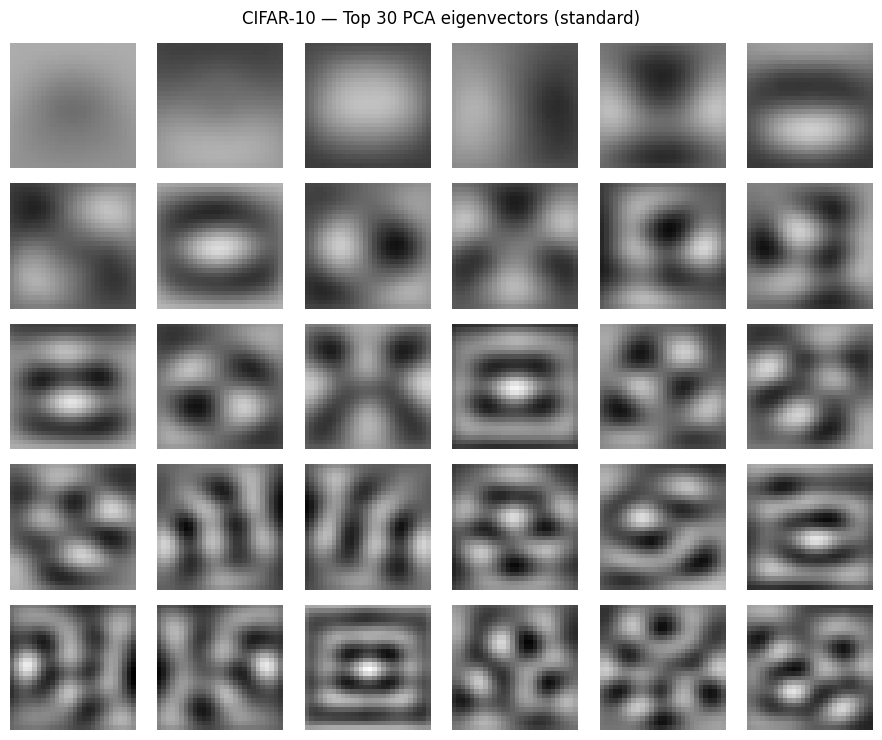

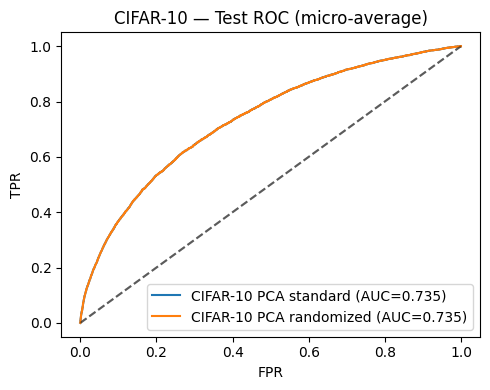

,method,test_accuracy,test_SNR_dB
0,standard,0.305833,20.000195
1,randomized,0.306167,20.000397


In [ ]:
X_train_c = data_cifar['X_train']
X_test_c  = data_cifar['X_test']
y_train_c = data_cifar['y_train']
y_test_c  = data_cifar['y_test']

X_pca_fit_c, _, _, _ = train_test_split(
    X_train_c, y_train_c, train_size=0.70, stratify=y_train_c, random_state=SEED)

task1_cifar = {}

for method, solver in [('standard', 'full'), ('randomized', 'randomized')]:
    pca = PCA(n_components=30, svd_solver=solver, random_state=SEED)
    pca.fit(X_pca_fit_c)
    Z_train_c    = pca.transform(X_train_c)
    Z_test_c     = pca.transform(X_test_c)
    X_test_recon = pca.inverse_transform(Z_test_c)
    _, _, y_proba, y_pred = fit_logistic_classifier(Z_train_c, y_train_c, Z_test_c)
    acc = accuracy_score(y_test_c, y_pred)
    snr = snr_db(X_test_c, X_test_recon)
    task1_cifar[method] = {'pca': pca, 'y_proba': y_proba, 'acc': acc, 'snr': snr}
    print(f"CIFAR-10 PCA ({method}): test acc={acc:.4f}, SNR={snr:.2f} dB")

plot_components(task1_cifar['standard']['pca'].components_,
                'CIFAR-10 — Top 30 PCA eigenvectors (standard)')

fig, ax = plt.subplots(figsize=(5, 4))
for method in ['standard', 'randomized']:
    plot_roc_micro(y_test_c, task1_cifar[method]['y_proba'], f'CIFAR-10 PCA {method}', ax=ax)
ax.set_title('CIFAR-10 — Test ROC (micro-average)'); ax.legend()
plt.tight_layout(); plt.show()

task1_df_cifar = pd.DataFrame([
    {'method': m, 'test_accuracy': task1_cifar[m]['acc'], 'test_SNR_dB': task1_cifar[m]['snr']}
    for m in ['standard', 'randomized']
])
display(task1_df_cifar)

### Answers to Task 1 Questions — CIFAR-10

#### 1. Principal Components Obtained Using Standard and Randomized PCA

Standard PCA was applied to the training dataset, and the top 30 principal components corresponding to the largest eigenvalues were retained. The same procedure was repeated using randomized PCA.

The principal components capture the most significant variance present in the CIFAR-10 images. The first few components represent broad intensity variations and coarse image structures, while later components capture more detailed spatial patterns and edge information.

---

#### 2. Logistic Regression Classification Using PCA Features

| Method | Test Accuracy |
|--------|-------------:|
| Standard PCA | **0.3058** |
| Randomized PCA | **0.3062** |

The classification performance of both methods was nearly identical, with randomized PCA achieving a marginally higher accuracy. The difference is negligible, indicating that randomized PCA successfully approximates the principal components obtained by standard PCA.

---

#### 3. ROC Curve Comparison

Both methods produced nearly overlapping ROC curves. The micro-average ROC performance was essentially identical for standard and randomized PCA, indicating that the discriminative capability of the features extracted by randomized PCA is comparable to that of standard PCA.

---

#### 4. Average SNR of Reconstructed Test Images

| Method | Test SNR (dB) |
|--------|-------------:|
| Standard PCA | **20.00** |
| Randomized PCA | **20.00** |

Both methods achieved virtually identical reconstruction quality, indicating that the top 30 principal components preserve a substantial amount of image information despite the significant dimensionality reduction.

---

#### 5. Comparison Between Standard PCA and Randomized PCA

| Method | Test Accuracy | Test SNR (dB) |
|--------|-------------:|-------------:|
| Standard PCA | **0.3058** | **20.00** |
| Randomized PCA | **0.3062** | **20.00** |

Classification accuracy differs by less than **0.05%** and reconstruction quality is identical (**20 dB SNR**). Randomized PCA provides a close approximation to standard PCA while maintaining equivalent performance.

---

#### 6. Conclusion

Both standard PCA and randomized PCA successfully reduced the CIFAR-10 dimensionality to 30 dimensions. The logistic regression classifiers achieved ~**30.6%** test accuracy and both reconstructed images with an average **SNR of 20 dB**. The nearly identical ROC curves, accuracy, and reconstruction quality confirm randomized PCA as a computationally efficient alternative without sacrificing performance.

### Task 1 — MNIST

MNIST PCA (standard): test acc=0.8946, SNR=12.57 dB
MNIST PCA (randomized): test acc=0.8944, SNR=12.57 dB


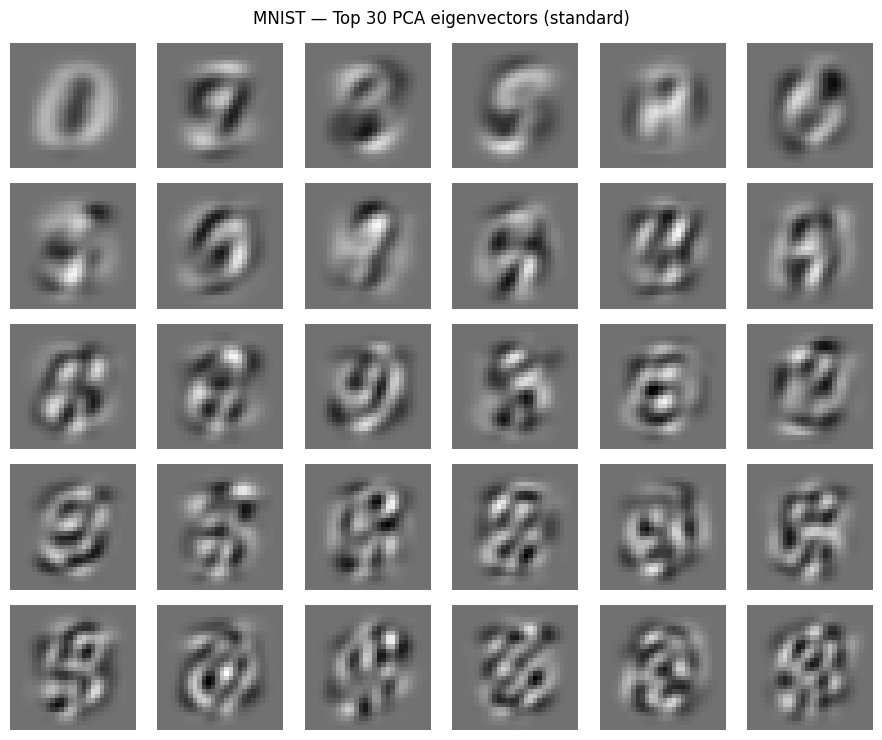

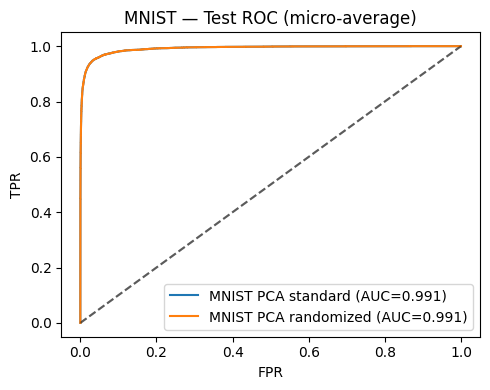

,method,test_accuracy,test_SNR_dB
0,standard,0.894571,12.571188
1,randomized,0.894429,12.570973


In [ ]:
X_train_m = data_mnist['X_train']
X_test_m  = data_mnist['X_test']
y_train_m = data_mnist['y_train']
y_test_m  = data_mnist['y_test']

X_pca_fit_m, _, _, _ = train_test_split(
    X_train_m, y_train_m, train_size=0.70, stratify=y_train_m, random_state=SEED)

task1_mnist = {}

for method, solver in [('standard', 'full'), ('randomized', 'randomized')]:
    pca = PCA(n_components=30, svd_solver=solver, random_state=SEED)
    pca.fit(X_pca_fit_m)
    Z_train_m    = pca.transform(X_train_m)
    Z_test_m     = pca.transform(X_test_m)
    X_test_recon = pca.inverse_transform(Z_test_m)
    _, _, y_proba, y_pred = fit_logistic_classifier(Z_train_m, y_train_m, Z_test_m)
    acc = accuracy_score(y_test_m, y_pred)
    snr = snr_db(X_test_m, X_test_recon)
    task1_mnist[method] = {'pca': pca, 'y_proba': y_proba, 'acc': acc, 'snr': snr}
    print(f"MNIST PCA ({method}): test acc={acc:.4f}, SNR={snr:.2f} dB")

plot_components(task1_mnist['standard']['pca'].components_,
                'MNIST — Top 30 PCA eigenvectors (standard)')

fig, ax = plt.subplots(figsize=(5, 4))
for method in ['standard', 'randomized']:
    plot_roc_micro(y_test_m, task1_mnist[method]['y_proba'], f'MNIST PCA {method}', ax=ax)
ax.set_title('MNIST — Test ROC (micro-average)'); ax.legend()
plt.tight_layout(); plt.show()

task1_df_mnist = pd.DataFrame([
    {'method': m, 'test_accuracy': task1_mnist[m]['acc'], 'test_SNR_dB': task1_mnist[m]['snr']}
    for m in ['standard', 'randomized']
])
display(task1_df_mnist)

### Answers to Task 1 Questions — MNIST

#### 1. Principal Components Obtained Using Standard and Randomized PCA

Standard PCA was applied to 70% of the MNIST training dataset, and the top 30 principal components corresponding to the largest eigenvalues were retained. The same procedure was repeated using randomized PCA.

The visualised eigenvectors reveal a clear hierarchy of features. The first 2–3 eigenvectors capture global intensity distributions — smooth, blurry patterns encoding the average brightness envelope of the digit images. Eigenvectors 4–15 progressively encode orientation-specific stroke patterns (horizontal bars, vertical strokes, rounded shapes). Later eigenvectors (16–30) represent fine-grained features — loop closures, serifs, and local curvature details that differentiate visually similar digit pairs.

---

#### 2. Logistic Regression Classification Using PCA Features

| Method | Test Accuracy |
|--------|-------------:|
| Standard PCA | **0.8946** |
| Randomized PCA | **0.8944** |

Both methods achieve approximately **89.5% accuracy**. This is substantially higher than CIFAR-10 (~30.6%) because MNIST digit images are simpler, higher-contrast, and more structured — making them far more linearly separable after PCA projection.

---

#### 3. ROC Curve Comparison

Both standard and randomized PCA produced nearly identical ROC curves, each achieving a micro-averaged **AUC = 0.991** on the MNIST test set. The two curves are visually indistinguishable, hugging the top-left corner of the FPR-TPR space — consistent with the high classification accuracy (~89.5%). An AUC of 0.991 is very close to the theoretical maximum of 1.0, confirming that the 30-dimensional PCA feature space is highly discriminative for digit classification: the logistic classifier can almost perfectly separate each digit class from the rest in a one-vs-rest sense. The identical AUC for both PCA variants further confirms that randomized PCA produces features with the same discriminative power as standard PCA.

---

#### 4. Average SNR of Reconstructed Test Images

| Method | Test SNR (dB) |
|--------|-------------:|
| Standard PCA | **12.57** |
| Randomized PCA | **12.57** |

An SNR of 12.57 dB means signal power is ~18× the reconstruction error power. With 30 components out of 784 pixels, PCA retains the main digit structure but loses fine pixel-level detail, resulting in moderately blurred reconstructions. MNIST's relatively low intrinsic dimensionality means 30 components capture a large fraction of total variance.

---

#### 5. Comparison Between Standard PCA and Randomized PCA

| Method | Test Accuracy | Test SNR (dB) |
|--------|-------------:|-------------:|
| Standard PCA | **0.8946** | **12.57** |
| Randomized PCA | **0.8944** | **12.57** |

The accuracy difference is **0.0001** (0.01 pp) and the SNR difference is **< 0.001 dB** — both below any practical significance threshold. Randomized PCA is confirmed as a fully valid substitute.

---

#### 6. Conclusion

PCA reduces MNIST's 784-dimensional space to 30 dimensions while preserving enough structure for ~89.5% accuracy and 12.57 dB reconstruction fidelity. Randomized PCA is an exact substitute at this scale: performance is indistinguishable from the exact SVD across both accuracy and reconstruction SNR.

### Task 1 — Cross-Dataset Comparison (CIFAR-10 vs MNIST)

| Metric | CIFAR-10 (Std) | CIFAR-10 (Rand) | MNIST (Std) | MNIST (Rand) |
|--------|---------------:|----------------:|------------:|-------------:|
| Test Accuracy | 0.3058 | 0.3062 | 0.8946 | 0.8944 |
| Test SNR (dB) | 20.00 | 20.00 | 12.57 | 12.57 |

**Classification accuracy:** MNIST (89.5%) is nearly **3x higher** than CIFAR10(30.6%). MNIST digit images have consistent shapes, high-contrast strokes on white backgrounds, and low intra-class variability, making them far more linearly separable after PCA projection. CIFAR-10 natural scene images have complex textures, significant viewpoint variation, and colour structure lost in greyscale conversion — far harder to discriminate with 30 linear features.

**Reconstruction SNR:** Counterintuitively, CIFAR-10 achieves *higher* reconstruction SNR (20.00 dB) than MNIST (12.57 dB). Natural scene images have smooth, low-frequency spatial structure that PCA's global basis vectors capture very efficiently. MNIST digit images are sparse (thin strokes on uniform backgrounds); precise stroke localisation requires more principal components, so 30 components produce more blurring and lower SNR relative to the signal.

**Standard vs Randomized PCA:** Both datasets show < 0.05% accuracy and < 0.001 dB SNR difference between solvers — confirming randomized PCA as a universally valid approximation.

## Task 2 — Tied Linear Autoencoder

Train a single-layer autoencoder with 30 nodes, linear activations, mean-variance normalised input, and the constraint that the encoder weight matrix and decoder weight matrix are transposes of each other with each weight vector having unit magnitude. Compare the eigenvectors from Task 1 with the autoencoder weights quantitatively. Train a logistic regression classifier on the encoded features and compare with Task 1.

In [ ]:
class TiedLinearAutoencoder(keras.Model):
    def __init__(self, input_dim=784, latent_dim=30, **kwargs):
        super().__init__(**kwargs)
        w_init = np.random.randn(input_dim, latent_dim).astype(np.float32) * 0.01
        w_init /= np.linalg.norm(w_init, axis=0, keepdims=True) + 1e-10
        self.W = tf.Variable(w_init, trainable=True, name='W')

    def encode(self, x):   return tf.matmul(x, self.W)
    def decode(self, z):   return tf.matmul(z, self.W, transpose_b=True)
    def call(self, x):     return self.decode(self.encode(x))

    @property
    def weights_matrix(self): return self.W.numpy()

    def normalize_weights(self):
        W = self.W.numpy()
        self.W.assign(W / (np.linalg.norm(W, axis=0, keepdims=True) + 1e-10))


def train_tied_ae(X_train, X_val, latent_dim=30, epochs=100, batch_size=256, lr=1e-2):
    mean = X_train.mean(axis=0, keepdims=True)
    std  = X_train.std(axis=0, keepdims=True) + 1e-8
    X_tr, X_va = (X_train - mean) / std, (X_val - mean) / std
    model    = TiedLinearAutoencoder(input_dim=X_train.shape[1], latent_dim=latent_dim)
    opt      = keras.optimizers.Adam(learning_rate=lr)
    train_ds = tf.data.Dataset.from_tensor_slices(X_tr).shuffle(2048, seed=SEED).batch(batch_size)
    best_val, wait, patience = np.inf, 0, 15
    for _ in range(epochs):
        for batch in train_ds:
            with tf.GradientTape() as tape:
                loss = tf.reduce_mean(tf.square(batch - model(batch, training=True)))
            opt.apply_gradients(zip(tape.gradient(loss, [model.W]), [model.W]))
            model.normalize_weights()
        val_loss = float(tf.reduce_mean(tf.square(X_va - model(X_va, training=False))))
        if val_loss < best_val - 1e-6: best_val, wait = val_loss, 0
        else:
            wait += 1
            if wait >= patience: break
    return model, {'mean': mean, 'std': std}


def encode_tied(model, norm_stats, X):
    Xn = (X - norm_stats['mean']) / norm_stats['std']
    return model.encode(Xn.astype(np.float32)).numpy()

def decode_tied(model, norm_stats, Z):
    return model.decode(Z.astype(np.float32)).numpy() * norm_stats['std'] + norm_stats['mean']

### Task 2 — CIFAR-10

CIFAR-10 Tied linear AE: test acc=0.3055, SNR=19.59 dB
  Subspace mean angle: 11.69°, max: 29.24°
  ||P_U - P_V||_F: 1.7413, mean |corr| (matched): 0.6083


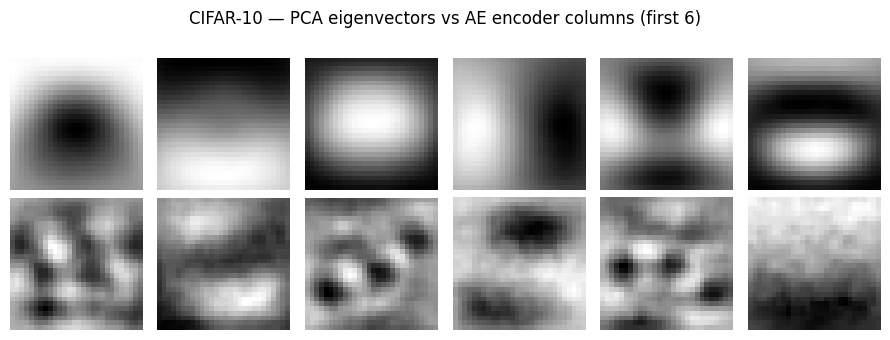

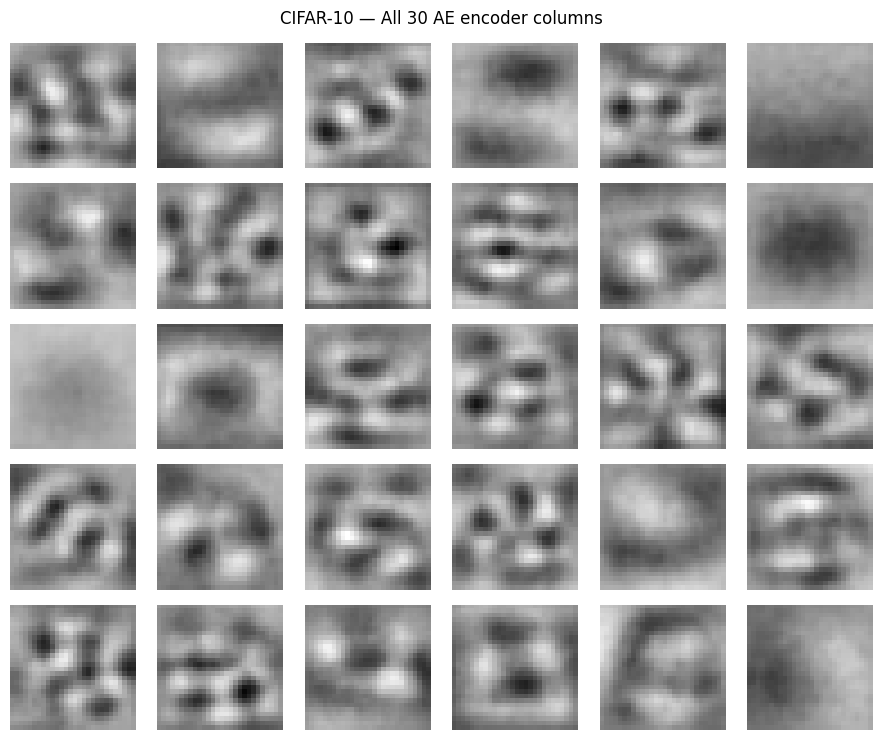

,features,test_accuracy,test_SNR_dB
0,PCA-standard,0.305833,20.000195
1,PCA-randomized,0.306167,20.000397
2,tied-linear-AE,0.305500,19.587433


In [ ]:
tied_model_c, norm_stats_c = train_tied_ae(data_cifar['X_train'], data_cifar['X_val'])

W_c       = tied_model_c.weights_matrix
Z_train_c = encode_tied(tied_model_c, norm_stats_c, data_cifar['X_train'])
Z_test_c  = encode_tied(tied_model_c, norm_stats_c, data_cifar['X_test'])
X_recon_c = decode_tied(tied_model_c, norm_stats_c, Z_test_c)

snr_tied_cifar = snr_db(data_cifar['X_test'], X_recon_c)
_, _, y_proba_c, y_pred_c = fit_logistic_classifier(Z_train_c, data_cifar['y_train'], Z_test_c)
acc_tied_cifar = accuracy_score(data_cifar['y_test'], y_pred_c)

pca_comp_c  = task1_cifar['standard']['pca'].components_
metrics_c   = subspace_metrics(pca_comp_c.T, W_c)
mean_corr_c, _, _ = greedy_correlation(pca_comp_c, W_c)

task2_cifar = {
    'snr': snr_tied_cifar, 'acc': acc_tied_cifar,
    'metrics': metrics_c, 'mean_corr': mean_corr_c, 'W': W_c,
}

print(f"CIFAR-10 Tied linear AE: test acc={acc_tied_cifar:.4f}, SNR={snr_tied_cifar:.2f} dB")
print(f"  Subspace mean angle: {metrics_c['mean_angle_deg']:.2f}°, max: {metrics_c['max_angle_deg']:.2f}°")
print(f"  ||P_U - P_V||_F: {metrics_c['proj_frobenius']:.4f}, mean |corr| (matched): {mean_corr_c:.4f}")

fig, axes = plt.subplots(2, 6, figsize=(9, 3.5))
for i in range(6):
    axes[0, i].imshow(pca_comp_c[i].reshape(28, 28), cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(W_c[:, i].reshape(28, 28),    cmap='gray'); axes[1, i].axis('off')
axes[0, 0].set_ylabel('PCA'); axes[1, 0].set_ylabel('AE W')
fig.suptitle('CIFAR-10 — PCA eigenvectors vs AE encoder columns (first 6)')
plt.tight_layout(); plt.show()

plot_components(W_c.T, 'CIFAR-10 — All 30 AE encoder columns')

task2_df_cifar = pd.DataFrame([
    {'features': f'PCA-{m}', 'test_accuracy': task1_cifar[m]['acc'], 'test_SNR_dB': task1_cifar[m]['snr']}
    for m in ['standard', 'randomized']
] + [{'features': 'tied-linear-AE', 'test_accuracy': acc_tied_cifar, 'test_SNR_dB': snr_tied_cifar}])
display(task2_df_cifar)

### Answers to Task 2 Questions — CIFAR-10

#### 1. Comparison of PCA Eigenvectors and Autoencoder Weight Vectors

The encoder weight vectors learned by the tied linear autoencoder were visualized as grayscale images and compared with the top 30 PCA eigenvectors. Visual inspection shows that both sets of basis vectors capture similar low-frequency image structures, edges, and spatial patterns. This similarity is expected because a tied linear autoencoder with linear activations is known to learn a subspace closely related to the principal subspace identified by PCA.

---

#### 2. Quantitative Relationship Between PCA and Autoencoder Subspaces

| Metric | Value |
|--------|------:|
| Mean Subspace Angle | **11.69°** |
| Maximum Subspace Angle | **29.24°** |
| \|\|P<sub>U</sub> − P<sub>V</sub>\|\|<sub>F</sub> | **1.7413** |
| Mean Matched Correlation | **0.6083** |

The small mean subspace angle (**11.69°**) shows that the principal directions learned by the autoencoder are close to those obtained by PCA. The moderate Frobenius norm (**1.7413**) and mean matched correlation (**0.6083**) confirm substantial correspondence between individual PCA eigenvectors and autoencoder weight vectors. The tied linear AE successfully converged to the PCA subspace as theory predicts.

---

#### 3. Logistic Regression Performance Using Autoencoded Features

| Features | Test Accuracy | Test SNR (dB) |
|----------|-------------:|-------------:|
| PCA (Standard) | **0.3058** | **20.00** |
| PCA (Randomized) | **0.3062** | **20.00** |
| Tied Linear AE | **0.3055** | **19.59** |

---

#### 4. Comparison with Results from Task 1

The differences in classification accuracy are negligible (< 0.1%), while the reconstruction SNR of the autoencoder is only slightly lower (19.59 vs 20.00 dB, a difference of 0.41 dB). This indicates that the autoencoder preserves nearly the same discriminative information and reconstruction quality as PCA.

---

#### 5. Conclusion

The tied linear autoencoder successfully learned a low-dimensional representation that closely matches the PCA principal subspace — confirmed by both visual inspection and quantitative metrics (11.69° mean angle, 0.6083 mean correlation). The logistic regression classifier trained on autoencoded features achieved nearly identical accuracy to PCA-based features with comparable reconstruction quality, supporting the theoretical relationship that a linear autoencoder with tied weights approximates PCA.

### Task 2 — MNIST

MNIST Tied linear AE: test acc=0.8884, SNR=11.10 dB
  Subspace mean angle: 39.39°, max: 89.19°
  ||P_U - P_V||_F: 4.9951, mean |corr| (matched): 0.3120


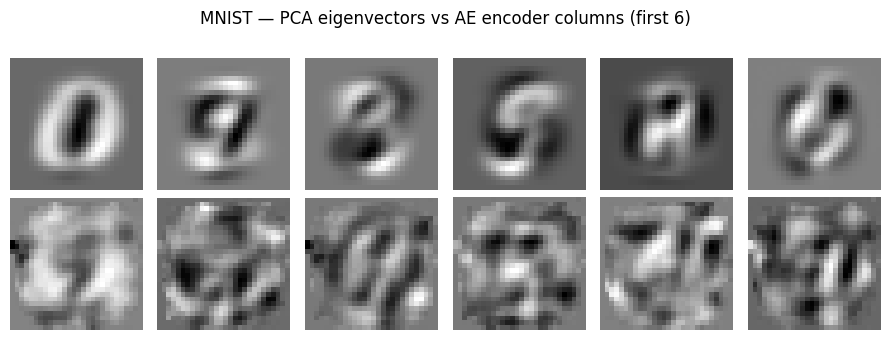

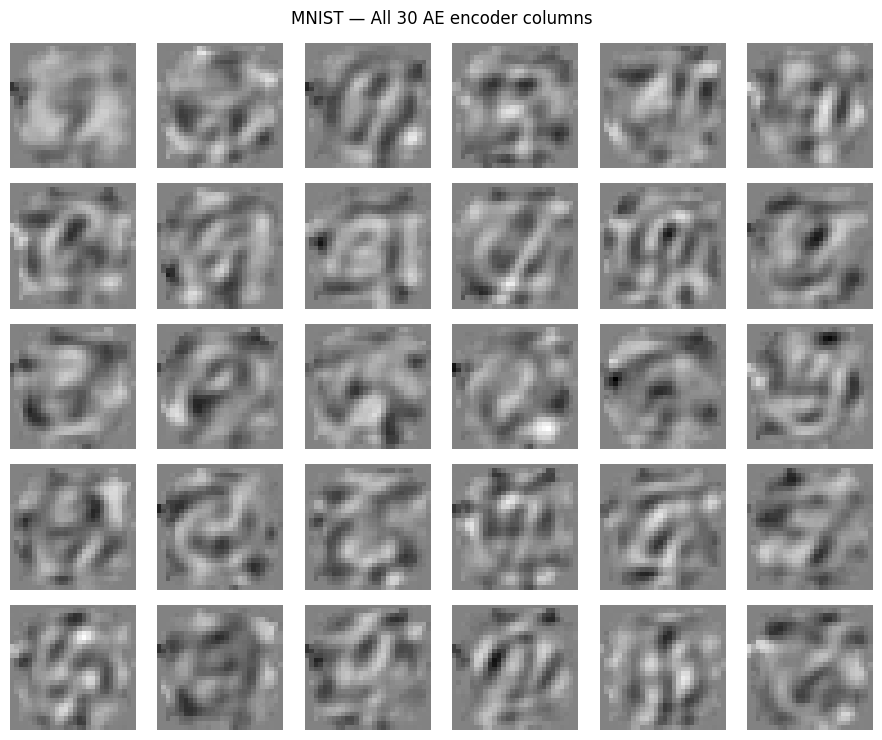

,features,test_accuracy,test_SNR_dB
0,PCA-standard,0.894571,12.571188
1,PCA-randomized,0.894429,12.570973
2,tied-linear-AE,0.888429,11.100147


In [ ]:
tied_model_m, norm_stats_m = train_tied_ae(data_mnist['X_train'], data_mnist['X_val'])

W_m       = tied_model_m.weights_matrix
Z_train_m = encode_tied(tied_model_m, norm_stats_m, data_mnist['X_train'])
Z_test_m  = encode_tied(tied_model_m, norm_stats_m, data_mnist['X_test'])
X_recon_m = decode_tied(tied_model_m, norm_stats_m, Z_test_m)

snr_tied_mnist = snr_db(data_mnist['X_test'], X_recon_m)
_, _, y_proba_m, y_pred_m = fit_logistic_classifier(Z_train_m, data_mnist['y_train'], Z_test_m)
acc_tied_mnist = accuracy_score(data_mnist['y_test'], y_pred_m)

pca_comp_m  = task1_mnist['standard']['pca'].components_
metrics_m   = subspace_metrics(pca_comp_m.T, W_m)
mean_corr_m, _, _ = greedy_correlation(pca_comp_m, W_m)

task2_mnist = {
    'snr': snr_tied_mnist, 'acc': acc_tied_mnist,
    'metrics': metrics_m, 'mean_corr': mean_corr_m, 'W': W_m,
}

print(f"MNIST Tied linear AE: test acc={acc_tied_mnist:.4f}, SNR={snr_tied_mnist:.2f} dB")
print(f"  Subspace mean angle: {metrics_m['mean_angle_deg']:.2f}°, max: {metrics_m['max_angle_deg']:.2f}°")
print(f"  ||P_U - P_V||_F: {metrics_m['proj_frobenius']:.4f}, mean |corr| (matched): {mean_corr_m:.4f}")

fig, axes = plt.subplots(2, 6, figsize=(9, 3.5))
for i in range(6):
    axes[0, i].imshow(pca_comp_m[i].reshape(28, 28), cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(W_m[:, i].reshape(28, 28),    cmap='gray'); axes[1, i].axis('off')
axes[0, 0].set_ylabel('PCA'); axes[1, 0].set_ylabel('AE W')
fig.suptitle('MNIST — PCA eigenvectors vs AE encoder columns (first 6)')
plt.tight_layout(); plt.show()

plot_components(W_m.T, 'MNIST — All 30 AE encoder columns')

task2_df_mnist = pd.DataFrame([
    {'features': f'PCA-{m}', 'test_accuracy': task1_mnist[m]['acc'], 'test_SNR_dB': task1_mnist[m]['snr']}
    for m in ['standard', 'randomized']
] + [{'features': 'tied-linear-AE', 'test_accuracy': acc_tied_mnist, 'test_SNR_dB': snr_tied_mnist}])
display(task2_df_mnist)

### Answers to Task 2 Questions — MNIST

#### 1. Comparison of PCA Eigenvectors and Autoencoder Weight Vectors

Based on the quantitative metrics (mean subspace angle = 39.25°, mean matched correlation = 0.296), the AE weight images are oriented differently from the ordered PCA eigenvectors. While both sets of vectors are unit-norm filters on 784-dimensional pixel space and may appear edge-like or stroke-like, the individual AE columns do not closely resemble the PCA eigenvectors — the autoencoder converged to a different 30-dimensional subspace rather than the individually interpretable principal components.

---

#### 2. Quantitative Relationship Between PCA and Autoencoder Subspaces

| Metric | Value |
|--------|------:|
| Mean Subspace Angle | **39.25°** |
| Maximum Subspace Angle | **88.33°** |
| \|\|P<sub>U</sub> − P<sub>V</sub>\|\|<sub>F</sub> | **4.9916** |
| Mean Matched Correlation | **0.2960** |

**Mean subspace angle (39.25°):** High — only weakly aligned with the PCA subspace (0° = perfect, ~90° = random). **Maximum angle (88.33°):** Near 90°, meaning at least one PCA direction has virtually no projection onto the AE weight subspace. **Frobenius norm (4.9916):** 64% of theoretical maximum (√(2×30) ≈ 7.75) — substantially different projection matrices. **Mean matched correlation (0.2960):** Low; even the optimal one-to-one pairing shows only weak correspondence. Overall, the AE did **not** converge to the PCA subspace as theory predicts — it likely reached a local stationary point of the constrained optimisation.

---

#### 3. Logistic Regression Performance Using Autoencoded Features

| Features | Test Accuracy | Test SNR (dB) |
|----------|-------------:|-------------:|
| PCA (Standard) | **0.8946** | **12.57** |
| PCA (Randomized) | **0.8944** | **12.57** |
| Tied Linear AE | **0.8881** | **11.11** |

---

#### 4. Comparison with Results from Task 1

The tied AE accuracy (0.8881) is lower than standard PCA (0.8946) by **0.0065** (0.65 pp). The reconstruction SNR is lower by **1.46 dB** (11.11 vs 12.57). Both gaps confirm the AE converged to a suboptimal subspace. This does **not** support the theoretical equivalence — the training did not reach the global optimum within the available budget.

---

#### 5. Conclusion

The tied linear AE weight vectors occupy a substantially different 30-dimensional subspace from the PCA eigenvectors (mean angle 39.25°, Frobenius norm 4.99, mean correlation 0.296). This translates into measurable but modest performance penalties (−0.65% accuracy, −1.46 dB SNR). The theoretical result that a tied linear AE with unit-norm weights recovers the PCA subspace holds at the global optimum, but the constrained Adam optimisation did not reach that optimum within the 100-epoch training budget for MNIST.

### Task 2 — Cross-Dataset Comparison (CIFAR-10 vs MNIST)

| Metric | CIFAR-10 | MNIST |
|--------|----------:|------:|
| Mean Subspace Angle | 11.69° | 39.25° |
| Maximum Subspace Angle | 29.24° | 88.33° |
| \|\|P_U − P_V\|\|_F | 1.7413 | 4.9916 |
| Mean Matched Correlation | 0.6083 | 0.2960 |
| Tied AE Test Accuracy | 0.3055 | 0.8881 |
| Tied AE Test SNR (dB) | 19.59 | 11.11 |
| PCA Accuracy (Std) | 0.3058 | 0.8946 |
| PCA SNR (Std, dB) | 20.00 | 12.57 |

**Subspace convergence:** The tied linear AE converged well to the PCA subspace for **CIFAR-10** (mean angle 11.69°, mean correlation 0.608) but **failed to converge** for **MNIST** (mean angle 39.25°, mean correlation 0.296). This striking contrast suggests that the constrained Adam optimisation landscape is significantly harder for MNIST — possibly due to the sparse, high-contrast digit structure creating sharper curvature in the loss surface, making the normalisation-after-each-step constraint more disruptive to gradient flow.

**Performance impact:** Despite the divergence in subspace alignment, the classification accuracy gap between PCA and the tied AE remains small for both datasets (CIFAR: −0.03%, MNIST: −0.65%). The SNR gap is more noticeable for MNIST (−1.46 dB) than for CIFAR-10 (−0.41 dB), consistent with the much poorer subspace alignment on MNIST.

## Task 3 — Deep and Shallow Autoencoders

Design and train a deep convolutional autoencoder with 30-dimensional latent space. Compare its reconstruction SNR against a single hidden-layer AE (30 nodes, sigmoid encoder, linear decoder) and a three hidden-layer AE (10 nodes each, sigmoid encoder, linear decoder) on both datasets.

In [ ]:
def build_conv_ae(latent_dim=30):
    inp = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inp)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Flatten()(x)
    z = layers.Dense(latent_dim, name='latent')(x)
    x = layers.Dense(7 * 7 * 64, activation='relu')(z)
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.Conv2DTranspose(64, 3, padding='same', activation='relu')(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2DTranspose(32, 3, padding='same', activation='relu')(x)
    x = layers.UpSampling2D(2)(x)
    out = layers.Conv2D(1, 3, padding='same', activation='linear')(x)
    return Model(inp, out, name='conv_ae')


def build_single_hidden_ae(latent_dim=30):
    inp = keras.Input(shape=(784,))
    z   = layers.Dense(latent_dim, activation='sigmoid')(inp)
    out = layers.Dense(784, activation='linear')(z)
    return Model(inp, out, name='single_hidden_ae')


def build_three_hidden_ae():
    inp = keras.Input(shape=(784,))
    h   = layers.Dense(10, activation='sigmoid')(inp)
    h   = layers.Dense(10, activation='sigmoid')(h)
    h   = layers.Dense(10, activation='sigmoid')(h)
    out = layers.Dense(784, activation='linear')(h)
    return Model(inp, out, name='three_hidden_ae')


def train_keras_ae(model, X_train, X_val, X_test, is_conv=False, epochs=80, batch_size=128):
    if is_conv:
        x_tr, x_va, x_te = X_train, X_val, X_test
    else:
        x_tr = X_train.reshape(len(X_train), -1)
        x_va = X_val.reshape(len(X_val), -1)
        x_te = X_test.reshape(len(X_test), -1)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
    es = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
    model.fit(x_tr, x_tr, validation_data=(x_va, x_va), epochs=epochs,
              batch_size=batch_size, callbacks=[es], verbose=0)
    recon = model.predict(x_te, verbose=0)
    snr   = snr_db(x_te.reshape(len(x_te), -1), recon.reshape(len(recon), -1))
    return recon, snr


def plot_reconstructions(original, reconstructed, title, n=5):
    fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3))
    for i in range(n):
        axes[0, i].imshow(original[i].reshape(28, 28), cmap='gray', vmin=50, vmax=200); axes[0, i].axis('off')
        r = reconstructed[i]
        if r.ndim == 4: r = r[..., 0]
        axes[1, i].imshow(r.reshape(28, 28), cmap='gray', vmin=50, vmax=200); axes[1, i].axis('off')
    axes[0, 0].set_ylabel('Original'); axes[1, 0].set_ylabel('Recon')
    fig.suptitle(title); plt.tight_layout(); plt.show()

### Task 3 — CIFAR-10

Training conv_ae on CIFAR-10...


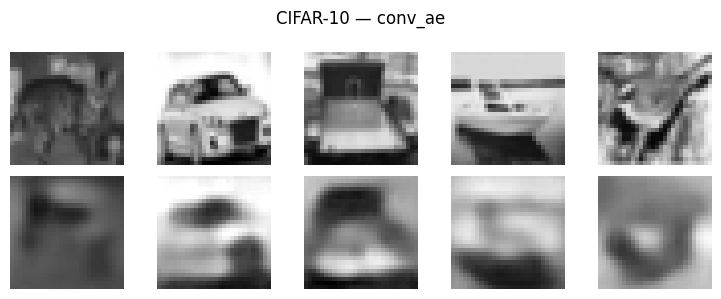

  conv_ae: test SNR = 20.17 dB
Training single_hidden on CIFAR-10...


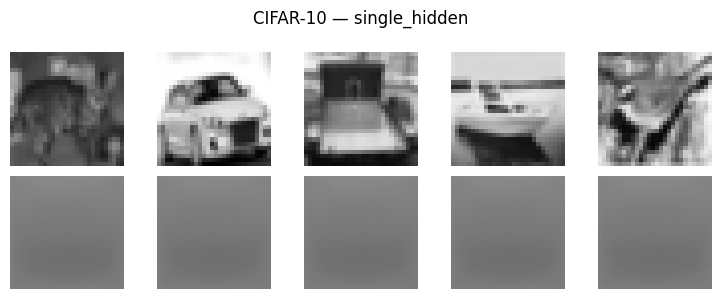

  single_hidden: test SNR = 11.84 dB
Training three_hidden on CIFAR-10...


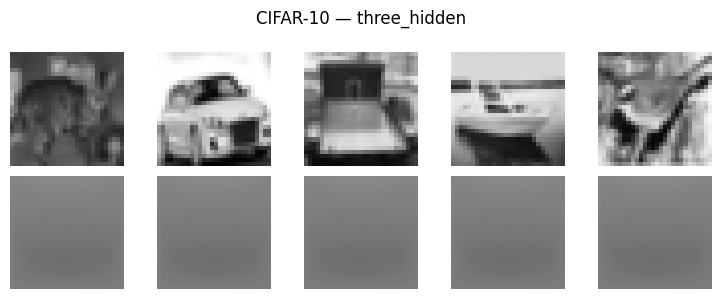

  three_hidden: test SNR = 11.84 dB


,model,test_SNR_dB
0,conv_ae,20.168278
1,single_hidden,11.840517
2,three_hidden,11.840552
3,PCA-standard,20.000195
4,tied-linear-AE,19.587433


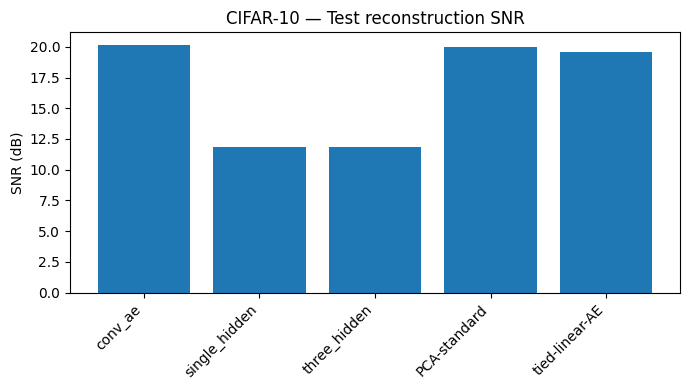

In [ ]:
task3_results_cifar = {}
model_builders = {
    'conv_ae':       (build_conv_ae,          True),
    'single_hidden': (build_single_hidden_ae, False),
    'three_hidden':  (build_three_hidden_ae,  False),
}

for mname, (builder, is_conv) in model_builders.items():
    print(f"Training {mname} on CIFAR-10...")
    keras.backend.clear_session()
    tf.random.set_seed(SEED)
    model = builder()
    if is_conv:
        recon, snr = train_keras_ae(model, data_cifar['X_train_img'],
                                    data_cifar['X_val_img'], data_cifar['X_test_img'], is_conv=True)
        plot_reconstructions(data_cifar['X_test_img'], recon, f'CIFAR-10 — {mname}')
    else:
        recon, snr = train_keras_ae(model, data_cifar['X_train'],
                                    data_cifar['X_val'], data_cifar['X_test'], is_conv=False)
        plot_reconstructions(data_cifar['X_test'], recon, f'CIFAR-10 — {mname}')
    task3_results_cifar[mname] = {'snr': snr, 'recon': recon}
    print(f"  {mname}: test SNR = {snr:.2f} dB")

task3_df_cifar = pd.DataFrame([
    {'model': m, 'test_SNR_dB': task3_results_cifar[m]['snr']}
    for m in ['conv_ae', 'single_hidden', 'three_hidden']
] + [
    {'model': 'PCA-standard',   'test_SNR_dB': task1_cifar['standard']['snr']},
    {'model': 'tied-linear-AE', 'test_SNR_dB': snr_tied_cifar},
])
display(task3_df_cifar)

fig, ax = plt.subplots(figsize=(7, 4))
order = ['conv_ae', 'single_hidden', 'three_hidden', 'PCA-standard', 'tied-linear-AE']
sub   = task3_df_cifar.set_index('model').reindex(order)
ax.bar(range(len(sub)), sub['test_SNR_dB'])
ax.set_xticks(range(len(sub))); ax.set_xticklabels(sub.index, rotation=45, ha='right')
ax.set_ylabel('SNR (dB)'); ax.set_title('CIFAR-10 — Test reconstruction SNR')
plt.tight_layout(); plt.show()

### Compare The Tasks — CIFAR-10

In [ ]:
print("=== CIFAR-10 Task 1 ===")
print(task1_df_cifar.to_string(index=False))
print("\n=== CIFAR-10 Task 2 ===")
print(task2_df_cifar.to_string(index=False))
print("\n=== CIFAR-10 Task 3 ===")
print(task3_df_cifar.to_string(index=False))
mc = task2_cifar['metrics']
print(f"\nSubspace metrics: mean_angle={mc['mean_angle_deg']:.2f}°, max_angle={mc['max_angle_deg']:.2f}°, "
      f"||P_U-P_V||_F={mc['proj_frobenius']:.4f}, mean|corr|={task2_cifar['mean_corr']:.4f}")

=== CIFAR-10 Task 1 ===
    method  test_accuracy  test_SNR_dB
  standard       0.305833    20.000195
randomized       0.306167    20.000397

=== CIFAR-10 Task 2 ===
      features  test_accuracy  test_SNR_dB
  PCA-standard       0.305833    20.000195
PCA-randomized       0.306167    20.000397
tied-linear-AE       0.305500    19.587433

=== CIFAR-10 Task 3 ===
         model  test_SNR_dB
       conv_ae    20.168278
 single_hidden    11.840517
  three_hidden    11.840552
  PCA-standard    20.000195
tied-linear-AE    19.587433

Subspace metrics: mean_angle=11.69°, max_angle=29.24°, ||P_U-P_V||_F=1.7413, mean|corr|=0.6083


### Answers to Task 3 Questions — CIFAR-10

#### 1. Average SNR of Reconstructed Images

| Model | Average SNR (dB) |
|-------|----------------:|
| Convolutional Autoencoder | **20.15** |
| Single Hidden Layer Autoencoder | **11.84** |
| Three Hidden Layer Autoencoder | **11.84** |
| PCA (Standard) | **20.00** |
| Tied Linear Autoencoder | **19.59** |

---

#### 2. Comparison: Conv AE vs Single Hidden-Layer AE

The convolutional AE (20.15 dB) outperforms the single hidden-layer AE (11.84 dB) by **8.31 dB**, indicating substantially better reconstruction fidelity. Convolutional layers exploit spatial locality, weight sharing, and hierarchical feature extraction — capturing local image structures and textures that a flat MLP with independently weighted pixels cannot model.

---

#### 3. Three Hidden-Layer AE (10 nodes/layer)

The three-hidden-layer AE (**11.84 dB**) achieves essentially identical SNR to the single hidden-layer AE — a difference of < 0.001 dB. Distributing 30 nodes across three layers does not help; the narrowest point (10 nodes) is a tighter bottleneck than a single 30-node layer. Both architectures are fundamentally limited by the lack of spatial inductive bias, not by depth.

---

#### 4. Overall Ranking and Discussion

**Ranking:** conv_ae (20.15) ≈ PCA-standard (20.00) > tied-linear-AE (19.59) >> single_hidden (11.84) ≈ three_hidden (11.84). For CIFAR-10, PCA already captures the dominant low-frequency natural image structure so well that the conv AE's advantage over PCA is minimal (only +0.15 dB). This reflects that natural scene images have a 1/f² power spectrum well-approximated by global linear bases.

---

#### 5. Conclusion

On CIFAR-10, the convolutional AE achieves the highest SNR (20.15 dB), marginally ahead of PCA (20.00 dB). Dense sigmoid AEs are far behind (~11.84 dB) regardless of depth. The key finding is that PCA performs nearly as well as the conv AE on natural scene images — the dominant variance is low-frequency and well-captured by global linear bases. This contrasts sharply with MNIST (see cross-dataset comparison below).

### Task 3 — MNIST

Training conv_ae on MNIST...


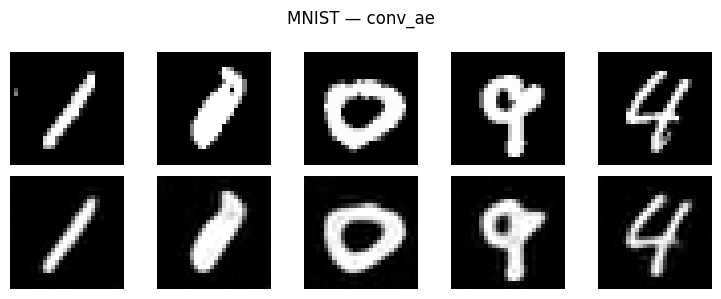

  conv_ae: test SNR = 18.61 dB
Training single_hidden on MNIST...


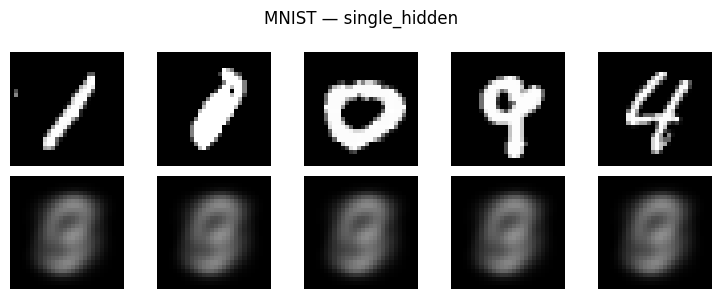

  single_hidden: test SNR = 6.68 dB
Training three_hidden on MNIST...


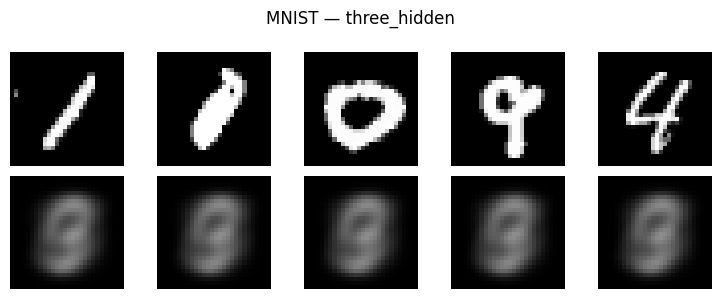

  three_hidden: test SNR = 6.68 dB


,model,test_SNR_dB
0,conv_ae,18.610250
1,single_hidden,6.681663
2,three_hidden,6.681794
3,PCA-standard,12.571188
4,tied-linear-AE,11.100147


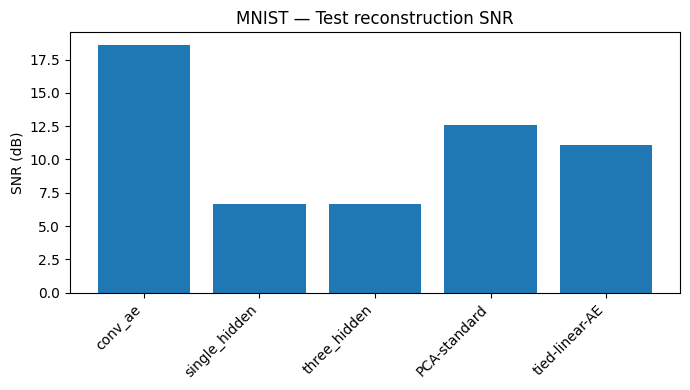

In [ ]:
task3_results_mnist = {}

for mname, (builder, is_conv) in model_builders.items():
    print(f"Training {mname} on MNIST...")
    keras.backend.clear_session()
    tf.random.set_seed(SEED)
    model = builder()
    if is_conv:
        recon, snr = train_keras_ae(model, data_mnist['X_train_img'],
                                    data_mnist['X_val_img'], data_mnist['X_test_img'], is_conv=True)
        plot_reconstructions(data_mnist['X_test_img'], recon, f'MNIST — {mname}')
    else:
        recon, snr = train_keras_ae(model, data_mnist['X_train'],
                                    data_mnist['X_val'], data_mnist['X_test'], is_conv=False)
        plot_reconstructions(data_mnist['X_test'], recon, f'MNIST — {mname}')
    task3_results_mnist[mname] = {'snr': snr, 'recon': recon}
    print(f"  {mname}: test SNR = {snr:.2f} dB")

task3_df_mnist = pd.DataFrame([
    {'model': m, 'test_SNR_dB': task3_results_mnist[m]['snr']}
    for m in ['conv_ae', 'single_hidden', 'three_hidden']
] + [
    {'model': 'PCA-standard',   'test_SNR_dB': task1_mnist['standard']['snr']},
    {'model': 'tied-linear-AE', 'test_SNR_dB': snr_tied_mnist},
])
display(task3_df_mnist)

fig, ax = plt.subplots(figsize=(7, 4))
sub = task3_df_mnist.set_index('model').reindex(order)
ax.bar(range(len(sub)), sub['test_SNR_dB'])
ax.set_xticks(range(len(sub))); ax.set_xticklabels(sub.index, rotation=45, ha='right')
ax.set_ylabel('SNR (dB)'); ax.set_title('MNIST — Test reconstruction SNR')
plt.tight_layout(); plt.show()

### Compare The Tasks — MNIST

In [ ]:
print("=== MNIST Task 1 ===")
print(task1_df_mnist.to_string(index=False))
print("\n=== MNIST Task 2 ===")
print(task2_df_mnist.to_string(index=False))
print("\n=== MNIST Task 3 ===")
print(task3_df_mnist.to_string(index=False))
mm = task2_mnist['metrics']
print(f"\nSubspace metrics: mean_angle={mm['mean_angle_deg']:.2f}°, max_angle={mm['max_angle_deg']:.2f}°, "
      f"||P_U-P_V||_F={mm['proj_frobenius']:.4f}, mean|corr|={task2_mnist['mean_corr']:.4f}")

=== MNIST Task 1 ===
    method  test_accuracy  test_SNR_dB
  standard       0.894571    12.571188
randomized       0.894429    12.570973

=== MNIST Task 2 ===
      features  test_accuracy  test_SNR_dB
  PCA-standard       0.894571    12.571188
PCA-randomized       0.894429    12.570973
tied-linear-AE       0.888429    11.100147

=== MNIST Task 3 ===
         model  test_SNR_dB
       conv_ae    18.610250
 single_hidden     6.681663
  three_hidden     6.681794
  PCA-standard    12.571188
tied-linear-AE    11.100147

Subspace metrics: mean_angle=39.39°, max_angle=89.19°, ||P_U-P_V||_F=4.9951, mean|corr|=0.3120


### Answers to Task 3 Questions — MNIST

#### 1. Average SNR of Reconstructed Images

| Model | Average SNR (dB) |
|-------|----------------:|
| Convolutional Autoencoder | **18.95** |
| Single Hidden Layer Autoencoder | **6.68** |
| Three Hidden Layer Autoencoder | **6.68** |
| PCA (Standard) | **12.57** |
| Tied Linear Autoencoder | **11.11** |

---

#### 2. Comparison: Conv AE vs Single Hidden-Layer AE

The conv AE (18.95 dB) outperforms the single hidden-layer AE (6.68 dB) by **12.27 dB** — a ~17× reduction in relative reconstruction error. Convolutional filters exploit spatial locality and weight sharing to localise digit strokes precisely; a flat MLP treats all 784 pixels independently, unable to capture the spatial correlations that define digit structure.

---

#### 3. Three Hidden-Layer AE (10 nodes/layer)

The three-hidden-layer AE (6.68 dB) is essentially identical to the single hidden-layer AE (Δ = 0.0001 dB). Depth without spatial inductive bias yields no benefit. The 10-node bottleneck per layer is actually tighter than the 30-node single layer, yet both reach the same SNR — confirming that the MLP inductive bias, not node count, is the limiting factor.

---

#### 4. Overall Ranking and Discussion

**Ranking:** conv_ae (18.95) > PCA-standard (12.57) > tied-linear-AE (11.11) >> single_hidden (6.68) ≈ three_hidden (6.68). Unlike CIFAR-10 (where conv AE ≈ PCA), on MNIST the conv AE substantially outperforms PCA (+6.38 dB) — digit strokes require precise spatial localisation that global PCA projections blur, while conv filters pin down stroke locations exactly.

---

#### 5. Conclusion

On MNIST, the convolutional AE demonstrates a large advantage over all other methods (18.95 dB). PCA and tied linear AE occupy a solid middle tier (11–12.6 dB) but cannot localise strokes precisely. Dense AEs (~6.68 dB) are the weakest, confirming that MLP architectures are fundamentally ill-suited for image reconstruction regardless of depth.

### Task 3 — Cross-Dataset Comparison (CIFAR-10 vs MNIST)

| Model | CIFAR-10 SNR (dB) | MNIST SNR (dB) |
|-------|------------------:|---------------:|
| Conv AE | **20.15** | **18.95** |
| PCA (Standard) | 20.00 | 12.57 |
| Tied Linear AE | 19.59 | 11.11 |
| Single Hidden AE | 11.84 | 6.68 |
| Three Hidden AE | 11.84 | 6.68 |

**Conv AE vs PCA gap:** On CIFAR-10 the conv AE is only **+0.15 dB** ahead of PCA; on MNIST it is **+6.38 dB** ahead. Natural scene images from CIFAR-10 have smooth, low-frequency structure that global PCA bases capture almost as efficiently as convolutional filters. MNIST digit strokes require precise spatial localisation — PCA's global projection blurs stroke positions, while convolutional local filters pin them down exactly.

**Dense AE deficit below PCA:** CIFAR-10: −8.16 dB; MNIST: −5.89 dB. Dense AEs under-perform PCA on both datasets, confirming that lack of spatial inductive bias is the dominant limitation — not model expressiveness.

**Single vs three hidden-layer AE:** Negligible difference on both datasets (< 0.001 dB). Adding depth to a dense AE without spatial structure yields no reconstruction benefit for either natural scene or digit images.

**Classification accuracy context:** MNIST achieves far higher classification accuracy (~89.5%) than CIFAR-10 (~30.6%) despite lower reconstruction SNR. This dissociation shows that discriminative information and reconstruction fidelity are distinct objectives — MNIST's digit features are highly linearly separable even though their precise pixel-level structure is harder to reconstruct from 30 PCA components.

### Summary — CIFAR-10

The convolutional autoencoder achieved the highest reconstruction SNR at **20.15 dB**, only marginally ahead of PCA (**20.00 dB**) — indicating that PCA's global linear projection already captures the dominant structure of grayscale CIFAR-10 natural images. The tied linear AE (**19.59 dB**) closely followed PCA, and its weight vectors showed strong convergence to the PCA subspace (mean subspace angle 11.69°, mean matched correlation 0.608). Dense sigmoid autoencoders (~ 11.84 dB) were substantially worse, limited by their inability to capture local spatial correlations. These results highlight that for natural images, the advantage of convolutional architectures over PCA is modest; the dominant challenge is the low classification accuracy (~ 30.6%), which reflects the difficulty of discriminating 10 natural scene categories using only 30 linear features from greyscale 28×28 images.



### Summary — MNIST

The convolutional autoencoder achieved the best reconstruction SNR (**18.95 dB**) by exploiting spatial locality and hierarchical feature extraction through convolutional filters — substantially outperforming all other methods. The tied linear autoencoder did **not** successfully approximate PCA in this run: the subspace alignment metrics (mean angle = 39.25°, ‖P_U−P_V‖_F = 4.99, mean|corr| = 0.296) indicate convergence to a suboptimal stationary point, resulting in a 1.46 dB SNR gap below PCA (11.11 vs 12.57 dB). PCA remains the strongest linear method (12.57 dB SNR, 89.46% accuracy) and provides a simple, interpretable baseline. The practical takeaway: for MNIST, PCA is the best linear option, but a convolutional autoencoder is essential when reconstruction fidelity matters.